# Shallow Neural Network from Scratch

A two-layer neural network built using only NumPy — no frameworks.

**Architecture:** `X → Z1 = W1·X + b1 → A1 = tanh(Z1) → Z2 = W2·A1 + b2 → A2 = sigmoid(Z2) → Loss`

Applied to the Cat vs Non-Cat dataset.

In [1]:
import numpy as np
from pathlib import Path
import h5py
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

## Load Data

Cat vs Non-Cat dataset — 209 training examples, 50 test examples.  
Each image is 64×64 RGB, flattened to a vector of 12,288 features.

In [2]:
def load_data():
    """Loads the cat vs non-cat dataset. Searches for datasets/ folder automatically."""
    
    # Search upward from notebook location to find datasets folder
    search_dir = Path().resolve()
    for _ in range(3):
        datasets_path = search_dir / 'datasets'
        if datasets_path.exists():
            break
        search_dir = search_dir.parent
    
    train = h5py.File(datasets_path / 'train_catvnoncat.h5', 'r')
    test  = h5py.File(datasets_path / 'test_catvnoncat.h5', 'r')
    
    X_train = np.array(train['train_set_x']) / 255.0
    y_train = np.array(train['train_set_y']).reshape(1, -1)
    
    X_test  = np.array(test['test_set_x']) / 255.0
    y_test  = np.array(test['test_set_y']).reshape(1, -1)
    
    # Flatten images: (m, 64, 64, 3) → (12288, m)
    X_train = X_train.reshape(X_train.shape[0], -1).T
    X_test  = X_test.reshape(X_test.shape[0], -1).T
    
    print(f"X_train shape: {X_train.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"X_test shape:  {X_test.shape}")
    print(f"y_test shape:  {y_test.shape}")
    
    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_data()

X_train shape: (12288, 209)
y_train shape: (1, 209)
X_test shape:  (12288, 50)
y_test shape:  (1, 50)


## Core Functions

### Forward Propagation
```
Z1 = W1·X + b1
A1 = tanh(Z1)              ← hidden layer uses tanh
Z2 = W2·A1 + b2
A2 = sigmoid(Z2)           ← output layer uses sigmoid
Loss = -1/m * sum(Y*log(A2) + (1-Y)*log(1-A2))
```

### Backward Propagation
```
dZ2 = A2 - Y                              ← output layer shortcut
dW2 = dZ2 · A1.T / m
db2 = sum(dZ2) / m

dZ1 = W2.T · dZ2  *  (1 - tanh(Z1)²)    ← tanh derivative
dW1 = dZ1 · X.T / m
db1 = sum(dZ1) / m
```

In [3]:
def sigmoid(z):
    """Applies sigmoid activation elementwise. Output is between 0 and 1."""
    return 1 / (1 + np.exp(-z))


def initialize_parameters(n_features, n_hidden):
    """Random initialization scaled by 0.01 to avoid saturation."""
    
    W1 = np.random.randn(n_hidden, n_features) * 0.01
    b1 = np.zeros((n_hidden, 1))
    
    W2 = np.random.randn(1, n_hidden) * 0.01
    b2 = np.zeros((1, 1))
    
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}


def propagate(X, y, parameters):
    """Forward pass + backward pass. Returns gradients and loss."""
    
    m = X.shape[1]
    W1, b1 = parameters['W1'], parameters['b1']
    W2, b2 = parameters['W2'], parameters['b2']

    # Forward pass
    Z1 = np.dot(W1, X) + b1
    A1 = np.tanh(Z1)                      # tanh for hidden layer

    Z2 = np.dot(W2, A1) + b2
    A2 = sigmoid(Z2)                       # sigmoid for output layer

    loss = -np.sum(y * np.log(A2) + (1 - y) * np.log(1 - A2)) / m

    # Backward pass
    # Output layer: dZ2 = A2 - Y  (chain rule shortcut for sigmoid + cross entropy)
    dZ2 = A2 - y
    dW2 = np.dot(dZ2, A1.T) / m
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m

    # Hidden layer: dZ1 = dL/dZ1 = (W2.T · dZ2) * tanh'(Z1)
    # tanh'(Z1) = 1 - tanh(Z1)^2 = 1 - A1^2
    dZ1 = np.dot(W2.T, dZ2) * (1 - A1 ** 2)
    dW1 = np.dot(dZ1, X.T) / m
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m

    gradients = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

    return gradients, loss


def optimize(X, y, parameters, learning_rate, epochs, print_cost):
    """Gradient descent loop. Updates weights and biases over epochs."""
    
    costs = []

    for i in range(epochs + 1):

        gradients, loss = propagate(X, y, parameters)
        costs.append(loss)

        parameters['W1'] -= learning_rate * gradients['dW1']
        parameters['b1'] -= learning_rate * gradients['db1']
        parameters['W2'] -= learning_rate * gradients['dW2']
        parameters['b2'] -= learning_rate * gradients['db2']

        if print_cost and i % 100 == 0:
            print(f"Iteration {i:4d}: Loss = {loss:.6f}")

    return parameters, costs


def predict(X, parameters):
    """Runs forward pass and thresholds at 0.5 to get binary predictions."""
    
    Z1 = np.dot(parameters['W1'], X) + parameters['b1']
    A1 = np.tanh(Z1)
    Z2 = np.dot(parameters['W2'], A1) + parameters['b2']
    A2 = sigmoid(Z2)

    return (A2 > 0.5).astype(int)


def model(X_train, y_train, n_hidden=4, learning_rate=0.01, epochs=1000, print_cost=False):
    """Ties everything together. Initializes, trains, and returns learned parameters."""
    
    parameters = initialize_parameters(X_train.shape[0], n_hidden)
    parameters, costs = optimize(X_train, y_train, parameters, learning_rate, epochs, print_cost)

    return parameters, costs

## Train the Model

In [4]:
parameters, costs = model(X_train, y_train, n_hidden=4, learning_rate=0.005, epochs=2000, print_cost=True)

Iteration    0: Loss = 0.693871
Iteration  100: Loss = 0.669040
Iteration  200: Loss = 0.652336
Iteration  300: Loss = 0.646463
Iteration  400: Loss = 0.642936
Iteration  500: Loss = 0.636828
Iteration  600: Loss = 0.626603
Iteration  700: Loss = 0.608900
Iteration  800: Loss = 0.587645
Iteration  900: Loss = 0.562929
Iteration 1000: Loss = 0.533372
Iteration 1100: Loss = 0.501077
Iteration 1200: Loss = 0.467460
Iteration 1300: Loss = 0.432635
Iteration 1400: Loss = 0.396955
Iteration 1500: Loss = 0.361376
Iteration 1600: Loss = 0.327021
Iteration 1700: Loss = 0.295048
Iteration 1800: Loss = 0.266087
Iteration 1900: Loss = 0.315867
Iteration 2000: Loss = 0.243503


## Evaluate Results

In [5]:
def evaluate(y_true, y_pred, name=""):
    """Prints accuracy, precision, recall, F1, and confusion matrix."""
    
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    
    acc       = 100 - np.mean(np.abs(y_pred - y_true)) * 100
    precision = precision_score(y_true, y_pred)
    recall    = recall_score(y_true, y_pred)
    f1        = f1_score(y_true, y_pred)
    
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\n--- {name} ---")
    print(f"Accuracy:  {acc:.2f}%")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"                 Predicted")
    print(f"                 Non-Cat  Cat")
    print(f"Actual Non-Cat  [{tn:^7}  {fp:^7}]")
    print(f"Actual Cat      [{fn:^7}  {tp:^7}]")


y_pred_train = predict(X_train, parameters)
y_pred_test  = predict(X_test, parameters)

evaluate(y_train, y_pred_train, "Train")
evaluate(y_test,  y_pred_test,  "Test")


--- Train ---
Accuracy:  94.26%
Precision: 1.0000
Recall:    0.8333
F1 Score:  0.9091

Confusion Matrix:
                 Predicted
                 Non-Cat  Cat
Actual Non-Cat  [  137       0   ]
Actual Cat      [  12       60   ]

--- Test ---
Accuracy:  62.00%
Precision: 0.8500
Recall:    0.5152
F1 Score:  0.6415

Confusion Matrix:
                 Predicted
                 Non-Cat  Cat
Actual Non-Cat  [  14        3   ]
Actual Cat      [  16       17   ]


## Training Cost Curve

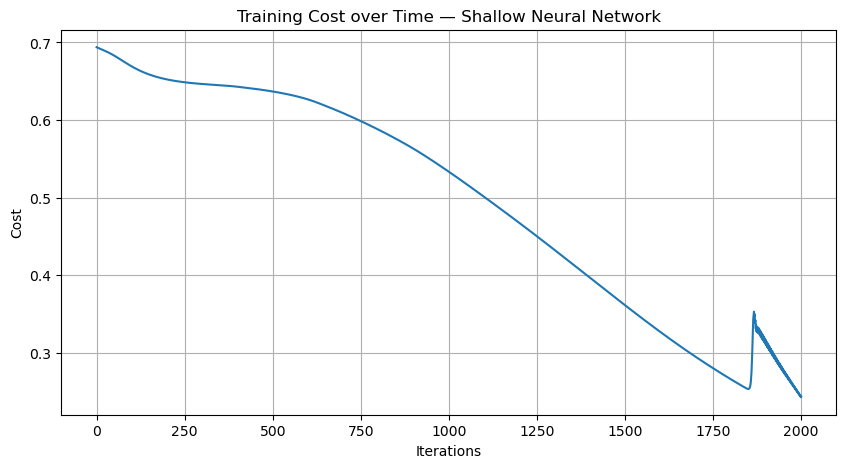

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(costs)
plt.ylabel('Cost')
plt.xlabel('Iterations')
plt.title('Training Cost over Time — Shallow Neural Network')
plt.grid(True)
plt.show()

## Observations

- Adding a hidden layer with tanh activation allows the network to learn non-linear decision boundaries
- Hidden layer uses **tanh** (not sigmoid) — tanh is zero-centered, avoids zig-zag gradient updates, converges faster
- Weights initialized with `* 0.01` — prevents saturation at the start of training
- Still a fully connected network — spatial structure of images is not captured

→ To learn spatial patterns: **[Deep Neural Network →](../03_deep_neural_network/)**